# Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# SMOTE
from imblearn.over_sampling import SMOTE

# Reproducibility
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT   = 'mlp_best.pt'

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.11.0+cu126
Device          : cuda


# Dataset

In [2]:
DATA_DIR = './cic_ids_2017/'

csv_files = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
for f in csv_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        df_tmp = pd.read_csv(path, encoding='utf-8', low_memory=False)
        dfs.append(df_tmp)
        print(f"Loaded  {f:60s}| rows: {len(df_tmp):>8,}")
    else:
        print(f"[SKIP]  File not found: {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows : {len(df):,}  |  Columns : {df.shape[1]}")

Loaded  Monday-WorkingHours.pcap_ISCX.csv                           | rows:  529,918
Loaded  Tuesday-WorkingHours.pcap_ISCX.csv                          | rows:  445,909
Loaded  Wednesday-workingHours.pcap_ISCX.csv                        | rows:  692,703
Loaded  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv      | rows:  170,366
Loaded  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv | rows:  288,602
Loaded  Friday-WorkingHours-Morning.pcap_ISCX.csv                   | rows:  191,033
Loaded  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv        | rows:  286,467
Loaded  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv            | rows:  225,745

Total rows : 2,830,743  |  Columns : 79


# Preprocessing

In [3]:
df.head(20)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,88,609,7,4,484,414,233,0,69.142857,111.967895,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,88,879,9,4,656,3064,313,0,72.888889,136.153814,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [6]:
print(df.columns)


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [7]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
print(df.columns)


Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags',
       'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length',
       'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s',
       'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean',
       'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count',
       'SYN_Flag_Co

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination_Port             int64  
 1   Flow_Duration                int64  
 2   Total_Fwd_Packets            int64  
 3   Total_Backward_Packets       int64  
 4   Total_Length_of_Fwd_Packets  int64  
 5   Total_Length_of_Bwd_Packets  int64  
 6   Fwd_Packet_Length_Max        int64  
 7   Fwd_Packet_Length_Min        int64  
 8   Fwd_Packet_Length_Mean       float64
 9   Fwd_Packet_Length_Std        float64
 10  Bwd_Packet_Length_Max        int64  
 11  Bwd_Packet_Length_Min        int64  
 12  Bwd_Packet_Length_Mean       float64
 13  Bwd_Packet_Length_Std        float64
 14  Flow_Bytes/s                 float64
 15  Flow_Packets/s               float64
 16  Flow_IAT_Mean                float64
 17  Flow_IAT_Std                 float64
 18  Flow_IAT_Max                 int64  
 19  

In [9]:
cols_to_drop = [
    'Fwd_Packet_Length_Max',
    'Fwd_Packet_Length_Min',
    'Fwd_Packet_Length_Std',
    'Bwd_Packet_Length_Max',
    'Bwd_Packet_Length_Min',
    'Bwd_Packet_Length_Mean',
    'Bwd_Packet_Length_Std',
    'Flow_IAT_Std',
    'Flow_IAT_Max',
    'Flow_IAT_Min',
    'Fwd_IAT_Std',
    'Fwd_IAT_Max',
    'Fwd_IAT_Min',
    'Bwd_IAT_Std',
    'Bwd_IAT_Max',
    'Bwd_IAT_Min',
    'Min_Packet_Length',
    'Max_Packet_Length',
    'Packet_Length_Std',
    'Active_Std',
    'Active_Max',
    'Active_Min',
    'Idle_Std',
    'Idle_Max',
    'Idle_Min'
]
df.drop(columns=cols_to_drop, inplace=True)

In [10]:
print(df.shape)

(2830743, 54)


In [11]:
df.columns = df.columns.str.strip()
LABEL_COL = 'Label'

print("Raw class distribution:")
print(df[LABEL_COL].value_counts())

Raw class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [12]:
# ── Strip whitespace from column names ────────────────────────────────────────
df.columns = df.columns.str.strip()

# ── Drop infinite and NaN values ──────────────────────────────────────────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"After cleaning : {len(df):,} rows")
print(f"Class distribution:\n{df['Label'].value_counts()}")

After cleaning : 2,827,876 rows
Class distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


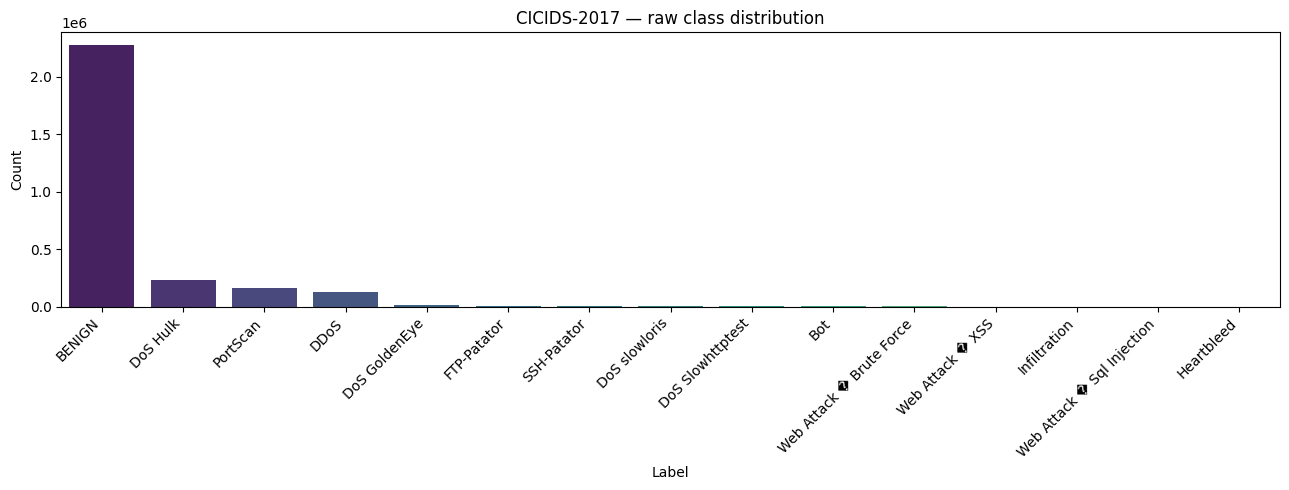

In [13]:
plt.figure(figsize=(13, 5))
counts = df[LABEL_COL].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('CICIDS-2017 — raw class distribution')
plt.tight_layout()
plt.show()

In [14]:
df.isnull().sum()
df.isna().sum()

Destination_Port               0
Flow_Duration                  0
Total_Fwd_Packets              0
Total_Backward_Packets         0
Total_Length_of_Fwd_Packets    0
Total_Length_of_Bwd_Packets    0
Fwd_Packet_Length_Mean         0
Flow_Bytes/s                   0
Flow_Packets/s                 0
Flow_IAT_Mean                  0
Fwd_IAT_Total                  0
Fwd_IAT_Mean                   0
Bwd_IAT_Total                  0
Bwd_IAT_Mean                   0
Fwd_PSH_Flags                  0
Bwd_PSH_Flags                  0
Fwd_URG_Flags                  0
Bwd_URG_Flags                  0
Fwd_Header_Length              0
Bwd_Header_Length              0
Fwd_Packets/s                  0
Bwd_Packets/s                  0
Packet_Length_Mean             0
Packet_Length_Variance         0
FIN_Flag_Count                 0
SYN_Flag_Count                 0
RST_Flag_Count                 0
PSH_Flag_Count                 0
ACK_Flag_Count                 0
URG_Flag_Count                 0
CWE_Flag_C

In [15]:
rename_classes = {
    'Web Attack � Brute Force' : 'Brute Force',
    'Web Attack � XSS' : 'XSS',
    'Web Attack � Sql Injection' : 'SQL Injection'

}

df[LABEL_COL] = df[LABEL_COL].map(rename_classes).fillna(df[LABEL_COL])
print(df[LABEL_COL].value_counts())

Label
BENIGN              2271320
DoS Hulk             230124
PortScan             158804
DDoS                 128025
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1956
Brute Force            1507
XSS                     652
Infiltration             36
SQL Injection            21
Heartbleed               11
Name: count, dtype: int64


In [16]:
label_map = {
    'BENIGN': 'Benign Traffic',
    'DoS Hulk': 'DoS Attacks',
    'DoS GoldenEye': 'DoS Attacks',
    'DoS slowloris': 'DoS Attacks',
    'DoS Slowhttptest': 'DoS Attacks',
    'DDoS': 'DDoS Attacks',
    'PortScan': 'Port Scanning & Brute Force',
    'FTP-Patator': 'Port Scanning & Brute Force',
    'SSH-Patator': 'Port Scanning & Brute Force',
    'Brute Force': 'Web-Based Attacks',
    'XSS': 'Web-Based Attacks',
    'SQL Injection': 'Web-Based Attacks',
    'Bot': 'Other Exploits & Infiltrations',
    'Infiltration': 'Other Exploits & Infiltrations',
    'Heartbleed': 'Other Exploits & Infiltrations'
}
df[LABEL_COL] = df[LABEL_COL].map(label_map).fillna(df[LABEL_COL])

print("Consolidated class distribution:")
print(df[LABEL_COL].value_counts())

Consolidated class distribution:
Label
Benign Traffic                    2271320
DoS Attacks                        251712
Port Scanning & Brute Force        172636
DDoS Attacks                       128025
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2003
Name: count, dtype: int64


In [ ]:
# label encode
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'].str.strip())

CLASS_NAMES = le.classes_.tolist()
n_classes   = len(CLASS_NAMES)
print(f"Classes ({n_classes}): {CLASS_NAMES}")

X = df.drop(columns=['Label'])
y = df['Label']

X = X.select_dtypes(include=[np.number])
print(f"Feature shape  : {X.shape}")

Classes (6): ['Benign Traffic', 'DDoS Attacks', 'DoS Attacks', 'Other Exploits & Infiltrations', 'Port Scanning & Brute Force', 'Web-Based Attacks']
Feature shape  : (2827876, 53)


In [ ]:
# train val test split
X_np = X.values.astype(np.float32)
y_np = y.astype(np.int64).values

X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y_np, test_size=0.30, stratify=y_np, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# normalize
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
joblib.dump(scaler, 'mlp_scaler.pkl')

print(f"Train : {X_train.shape[0]:,}  Val : {X_val.shape[0]:,}  Test : {X_test.shape[0]:,}")

Train : 1,979,513  Val : 424,181  Test : 424,182


# SMOTE

In [19]:
print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

# ── Safe k_neighbors for very rare classes (Infiltration=36, Heartbleed=11) ───
min_samples = min(Counter(y_train).values())
k = min(5, min_samples - 1)
print(f"Using k_neighbors = {k}")

sm = SMOTE(random_state=SEED, k_neighbors=k)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After  SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))
print(f"Train size after SMOTE : {X_train_sm.shape[0]:,}")

Before SMOTE: {np.int64(0): np.int64(1589924), np.int64(1): np.int64(89618), np.int64(2): np.int64(176198), np.int64(3): np.int64(1402), np.int64(4): np.int64(120845), np.int64(5): np.int64(1526)}
Using k_neighbors = 5
After  SMOTE: {np.int64(0): np.int64(1589924), np.int64(1): np.int64(1589924), np.int64(2): np.int64(1589924), np.int64(3): np.int64(1589924), np.int64(4): np.int64(1589924), np.int64(5): np.int64(1589924)}
Train size after SMOTE : 9,539,544


# MLP Model Setup

In [ ]:
# MLP 
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Block 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Block 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


INPUT_DIM = X_train_sm.shape[1]

mlp_model = MLP(INPUT_DIM, n_classes).to(DEVICE)

print(mlp_model)
print(f"\nTotal Parameters : {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Device           : {DEVICE}")
print(f"Input Features   : {INPUT_DIM}  |  Classes : {n_classes}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=53, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=6, bias=True)
  )
)

Total Parameters : 194,438
Device           : cuda
Input Features   : 53  |  Classes : 6


In [ ]:

BATCH_SIZE = 1024

X_train_t = torch.tensor(X_train_sm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_sm, dtype=torch.long)
X_val_t   = torch.tensor(X_val,      dtype=torch.float32)
y_val_t   = torch.tensor(y_val,      dtype=torch.long)
X_test_t  = torch.tensor(X_test,     dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}  |  Val batches : {len(val_loader)}  |  Test batches : {len(test_loader)}")

Train batches : 9316  |  Val batches : 415  |  Test batches : 415


In [ ]:

raw_weights   = compute_class_weight('balanced',
                                      classes=np.unique(y_train_sm),
                                      y=y_train_sm)
class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

print("Class weights:")
for name, w in zip(CLASS_NAMES, raw_weights):
    print(f"  {name:35s}: {w:.4f}")

Class weights:
  Benign Traffic                     : 1.0000
  DDoS Attacks                       : 1.0000
  DoS Attacks                        : 1.0000
  Other Exploits & Infiltrations     : 1.0000
  Port Scanning & Brute Force        : 1.0000
  Web-Based Attacks                  : 1.0000


# Training with Early Stopping

In [ ]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 10     # stop if val_loss doesn't improve for 10 epochs

# Loss with class weights → directly improves Macro F1 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# ── History storage ───────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_loss = np.inf
no_improve    = 0

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>10}  {'Train Acc':>10}  {'Val Acc':>8}  Status")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):

    # Train 
    mlp_model.train()
    train_loss, train_correct = 0.0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        out  = mlp_model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(X_b)
        train_correct += (out.argmax(1) == y_b).sum().item()
    train_loss /= len(train_loader.dataset)
    train_acc   = train_correct / len(train_loader.dataset)

    # Validate 
    mlp_model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out       = mlp_model(X_b)
            val_loss += criterion(out, y_b).item() * len(X_b)
            val_correct += (out.argmax(1) == y_b).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc   = val_correct / len(val_loader.dataset)

    scheduler.step()

    # Store history 
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early Stopping 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : mlp_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'            : best_val_loss
        }, CKPT)
        status = 'improved ✅'
    else:
        no_improve += 1
        status = f'no improve ({no_improve}/{PATIENCE})'

    print(f"{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.4f}  {val_acc:>8.4f}  {status}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}!")
        break

best_epoch = int(np.argmin(history['val_loss'])) + 1
print(f"\nTraining complete ✅")
print(f"Best Epoch    : {best_epoch}")
print(f"Best Val Loss : {min(history['val_loss']):.4f}")
print(f"Best Val Acc  : {max(history['val_acc']):.4f}")

 Epoch  Train Loss    Val Loss   Train Acc   Val Acc  Status
---------------------------------------------------------------------------
     1      0.0816      0.1360      0.9744    0.9578  improved ✅
     2      0.0486      0.1383      0.9857    0.9558  no improve (1/10)
     3      0.0447      0.1155      0.9869    0.9621  improved ✅
     4      0.0427      0.1218      0.9876    0.9603  no improve (1/10)
     5      0.0421      0.1298      0.9878    0.9603  no improve (2/10)
     6      0.0417      0.1101      0.9879    0.9646  improved ✅
     7      0.0412      0.1381      0.9881    0.9550  no improve (1/10)
     8      0.0416      0.1136      0.9880    0.9632  no improve (2/10)
     9      0.0408      0.1482      0.9883    0.9523  no improve (3/10)
    10      0.0417      0.1145      0.9879    0.9624  no improve (4/10)
    11      0.0415      0.1174      0.9880    0.9611  no improve (5/10)
    12      0.0413      0.1104      0.9881    0.9643  no improve (6/10)
    13      0.0412  

# Evaluation

In [ ]:
# Load best checkpoint 
mlp_model.load_state_dict(
    torch.load(CKPT, map_location=DEVICE)['model_state_dict']
)
print("Best MLP model loaded ✅\n")

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    preds, labels = [], []
    for X_b, y_b in loader:
        preds.extend(model(X_b.to(device)).argmax(1).cpu().numpy())
        labels.extend(y_b.numpy())
    return np.array(preds), np.array(labels)

y_pred, y_te = get_predictions(mlp_model, test_loader, DEVICE)

acc      = accuracy_score(y_te, y_pred)
prec_w   = precision_score(y_te, y_pred, average='weighted', zero_division=0)
rec_w    = recall_score(y_te,    y_pred, average='weighted', zero_division=0)
f1_w     = f1_score(y_te,        y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_te,        y_pred, average='macro',    zero_division=0)

print("=" * 55)
print(f"  Test Accuracy  : {acc  * 100:.4f}%")
print(f"  Precision      : {prec_w:.4f}  (weighted)")
print(f"  Recall         : {rec_w:.4f}  (weighted)")
print(f"  F1-score       : {f1_w:.4f}  (weighted)")
print(f"  Macro F1       : {f1_macro:.4f}  (macro)")
print("=" * 55)
print("\nClassification Report:\n")
print(classification_report(y_te, y_pred,
                             target_names=CLASS_NAMES, digits=4,
                             zero_division=0))

Best MLP model loaded ✅

  Test Accuracy  : 96.4643%
  Precision      : 0.9807  (weighted)
  Recall         : 0.9646  (weighted)
  F1-score       : 0.9713  (weighted)
  Macro F1       : 0.6983  (macro)

Classification Report:

                                precision    recall  f1-score   support

                Benign Traffic     0.9999    0.9574    0.9782    340698
                  DDoS Attacks     0.9415    0.9999    0.9698     19204
                   DoS Attacks     0.9419    0.9986    0.9694     37757
Other Exploits & Infiltrations     0.0621    0.9900    0.1170       300
   Port Scanning & Brute Force     0.8342    0.9830    0.9025     25896
             Web-Based Attacks     0.1449    0.9939    0.2529       327

                      accuracy                         0.9646    424182
                     macro avg     0.6541    0.9871    0.6983    424182
                  weighted avg     0.9807    0.9646    0.9713    424182



# Visualization

In [25]:
STYLE      = dict(linewidth=2)
epochs_ran = range(1, len(history['train_loss']) + 1)
best_epoch = int(np.argmin(history['val_loss'])) + 1

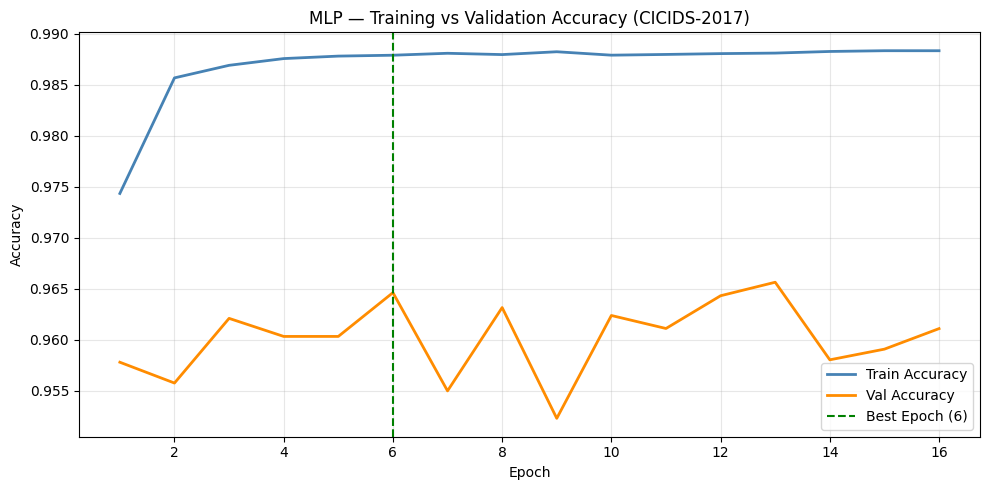

In [ ]:
# training vs Validation Accuracy 
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history['train_acc'], label='Train Accuracy', color='steelblue',  **STYLE)
plt.plot(epochs_ran, history['val_acc'],   label='Val Accuracy',   color='darkorange', **STYLE)
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('MLP — Training vs Validation Accuracy (CICIDS-2017)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('mlp_accuracy.png', dpi=150); plt.show()

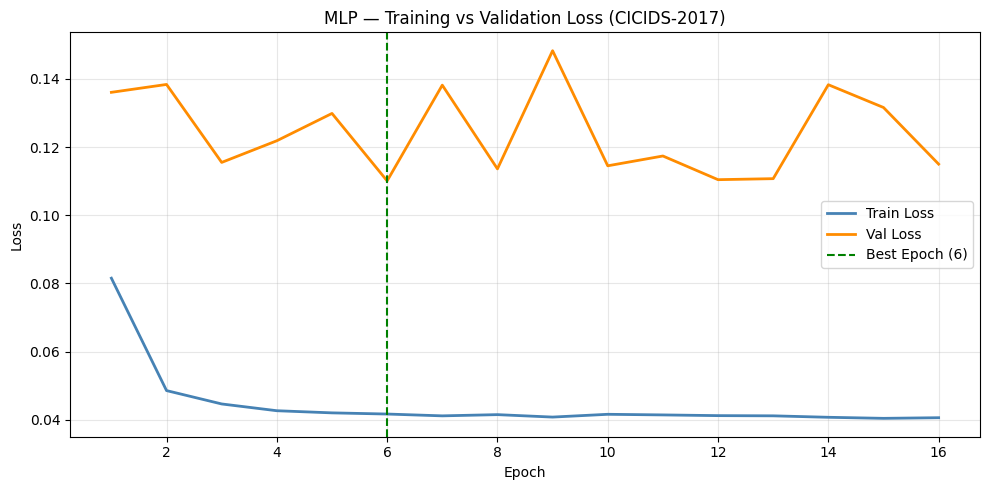

In [ ]:
# Training vs Validation Loss 
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue',  **STYLE)
plt.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='darkorange', **STYLE)
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('MLP — Training vs Validation Loss (CICIDS-2017)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('mlp_loss.png', dpi=150); plt.show()

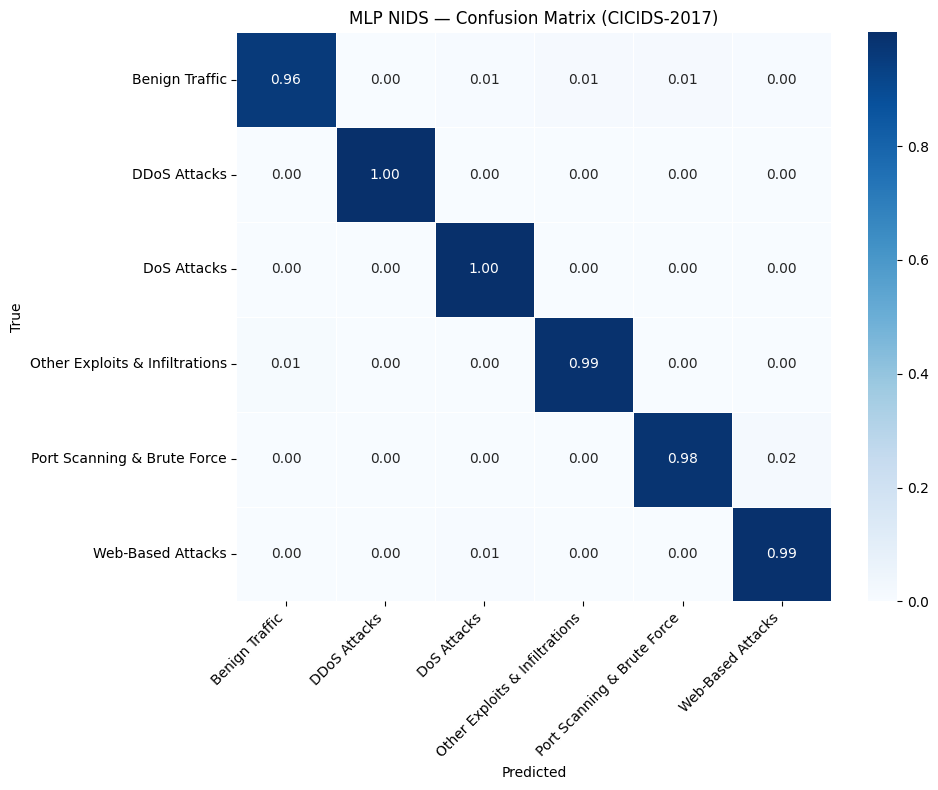

In [ ]:

cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
plt.title('MLP NIDS — Confusion Matrix (CICIDS-2017)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=150); plt.show()

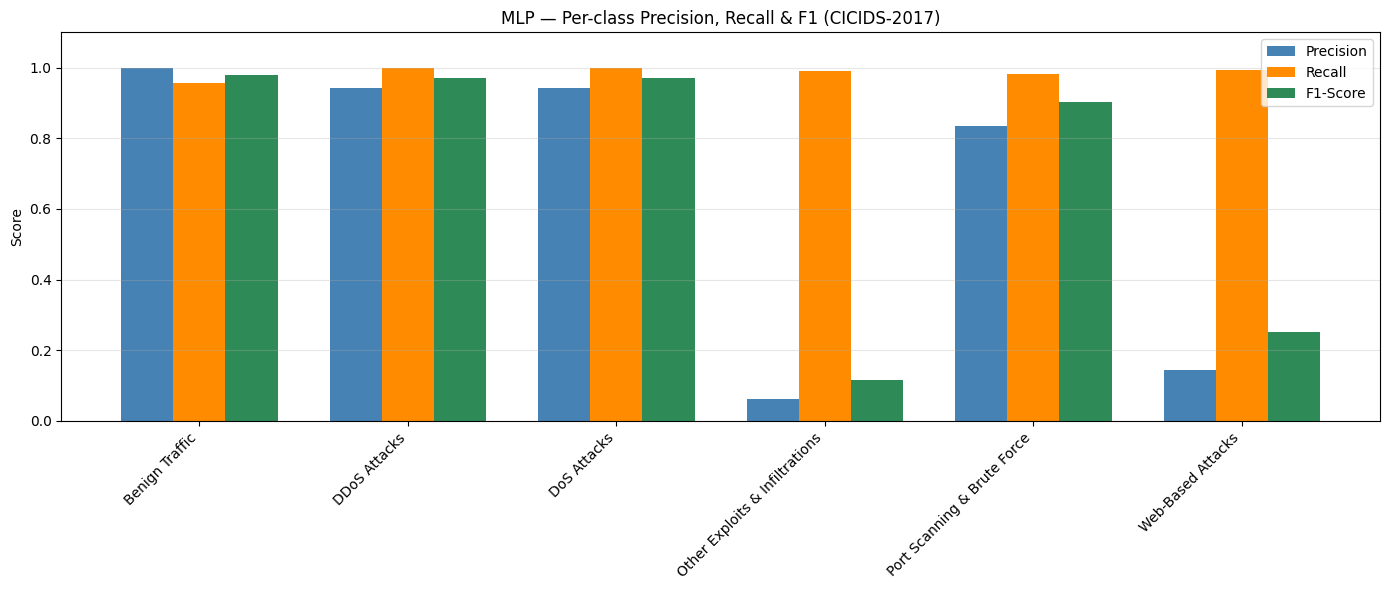

In [ ]:

report    = classification_report(y_te, y_pred,
                                   target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score']]

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, report_df['precision'], width, label='Precision', color='steelblue')
ax.bar(x,         report_df['recall'],    width, label='Recall',    color='darkorange')
ax.bar(x + width, report_df['f1-score'],  width, label='F1-Score',  color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.legend()
ax.set_title('MLP — Per-class Precision, Recall & F1 (CICIDS-2017)')
ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('mlp_per_class_metrics.png', dpi=150); plt.show()

# Saving

In [ ]:
# model

print(f"Model saved    → {CKPT} ✅")

# scaler & Label Encoder 
joblib.dump(scaler, 'mlp_scaler.pkl')
joblib.dump(le,     'mlp_label_encoder.pkl')
print("Scaler saved   → mlp_scaler.pkl ✅")
print("LEncoder saved → mlp_label_encoder.pkl ✅")

#  Metrics CSV 
metrics_df = pd.DataFrame([{
    'model'              : 'MLP',
    'accuracy'           : acc,
    'precision_weighted' : prec_w,
    'recall_weighted'    : rec_w,
    'f1_weighted'        : f1_w,
    'f1_macro'           : f1_macro,
    'best_epoch'         : best_epoch,
}])
metrics_df.to_csv('mlp_metrics.csv', index=False)
print("Metrics saved  → mlp_metrics.csv ✅")


Model saved    → mlp_best.pt ✅
Scaler saved   → mlp_scaler.pkl ✅
LEncoder saved → mlp_label_encoder.pkl ✅
Metrics saved  → mlp_metrics.csv ✅
